In [214]:
#Name: Alexandro Galvez-Vega
#Team:
#Class: CAP 5625-042 Computational Foundations Of AI
#Professor: Michael DeGiorgio

In [215]:
#Starting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

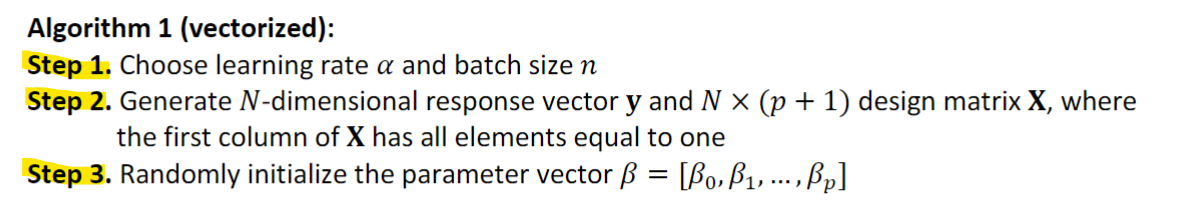

In [216]:
#Getting image
image_load = 'VectorizedAlgo1.png'

# # Display the image
Image(filename=image_load) 

In [217]:
#filename takes in the name of the csv file
#read_csv lets us make a dataframe

filename = "Advertising_N200_p3.csv"
advertising_df = pd.read_csv(filename)

#This dataframe is quickly split between the features that will be used for x
#The actual y turnout is also split and it will be compared to a predictive y at the very end
x_features_df = advertising_df.copy(deep = True)

y_features_df = x_features_df.pop('sales') 






In [218]:
#Split check for x features
print(x_features_df.head(100))

       TV  radio  newspaper
0   230.1   37.8       69.2
1    44.5   39.3       45.1
2    17.2   45.9       69.3
3   151.5   41.3       58.5
4   180.8   10.8       58.4
..    ...    ...        ...
95  163.3   31.6       52.9
96  197.6    3.5        5.9
97  184.9   21.0       22.0
98  289.7   42.3       51.2
99  135.2   41.7       45.9

[100 rows x 3 columns]


In [219]:
#Split check for true result y
print(y_features_df.head(100))

0     22.1
1     10.4
2      9.3
3     18.5
4     12.9
      ... 
95    16.9
96    11.7
97    15.5
98    25.4
99    17.2
Name: sales, Length: 100, dtype: float64


In [220]:

#We add a dummy 1 column for the future matrix math involving beta which will include a beta_0
x_features_add1 = x_features_df.assign(dummy=1)
moving_column = x_features_add1.pop('dummy') 
x_features_add1.insert(0, 'beta_0', moving_column)




#This establishes all the variables we need and noted in the a1 notes
#The below notes the learning rate
##"I would consider a learning rate of 𝛼 = 2.5 × 10−6"
learning_rate_alpha = 2.5 * (10 ** -6)
#An adjusted learning rate that yields interesting results
#learning_rate_alpha = 2.5 * (10 ** -7)

#learning_rate_alpha = 2.5 * (10 ** -10) Gets too small and totally breaks the MSE

#The batch size determined for a1 is 10
batch_size_n = 10  

#We get the total number of observations involved
observations_total_N = len(advertising_df)

#We note the total number of features too
feature_total_p = len(x_features_add1.columns)

#The dataframes are converted to numpy arrays to allow for the matrix math that is going to be involved
X = x_features_add1.to_numpy()



y = y_features_df.to_numpy()

#This is also provided a1 and represents the bath based on the batch_size_n noted split
batch_B = observations_total_N // batch_size_n  


#"Note, that a standardized coefficients are always in a range between -1 and +1"
#Random is used to give us a random initial beta, -1 and 1 are used as a range
initial_beta = np.random.uniform(-1, 1, feature_total_p)




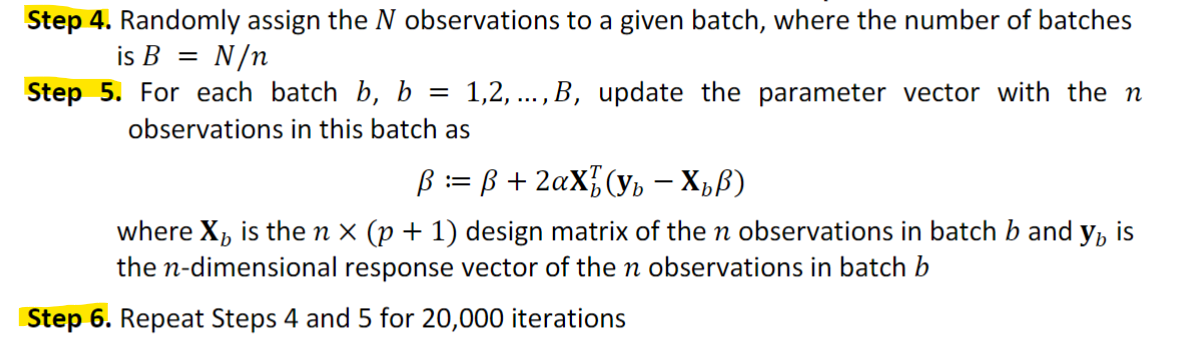

In [221]:
#Getting image
image_load = 'VectorizedAlgo2.png'

# # Display the image
Image(filename=image_load) 

In [222]:

#This is redundant but I set beta to initial beta
#I wanted to have a variable specifically for the intial randomally set beta
intermediary_beta = initial_beta
#Beta refined will act as final beta
#This is also a little redundant but I want a clear variable for this as well

#Placeholder until final values are estbalished
vector_param_beta = initial_beta

#
record_of_v_beta = []
cost_history = []

#The iteration loop size is set to 20,000
# _ is used instead of commas for python
iter_loop_size = 20_000

In [223]:


#This is the iteration for loop
for iter_c in range(iter_loop_size):
    #This is going to reorder everything
    random_reorder = np.random.permutation(observations_total_N)
    

    
    ######

    #This loop is is for the split batches
    for item_b in range(batch_B):
        #Each item in the batch is created for x and y using slices at specific index ranges
        slice_launch_index = item_b * batch_size_n
        slice_last_index = (item_b + 1) * batch_size_n
        slice_launch_to_last = np.arange(slice_launch_index, slice_last_index)

        #batches set
        current_X_batch = X[random_reorder][slice_launch_to_last]
        current_y_batch = y[random_reorder][slice_launch_to_last]

        #X transpose is needed for the equation
        X_batch_transposed = np.transpose(current_X_batch)

        #The math here can be found from a1
        intermediary_beta += 2 * learning_rate_alpha * X_batch_transposed.dot(current_y_batch - current_X_batch.dot(intermediary_beta))


    record_of_v_beta.append(intermediary_beta.copy())
    cost = np.sum((y - X.dot(intermediary_beta))**2)
    cost_history.append(cost)












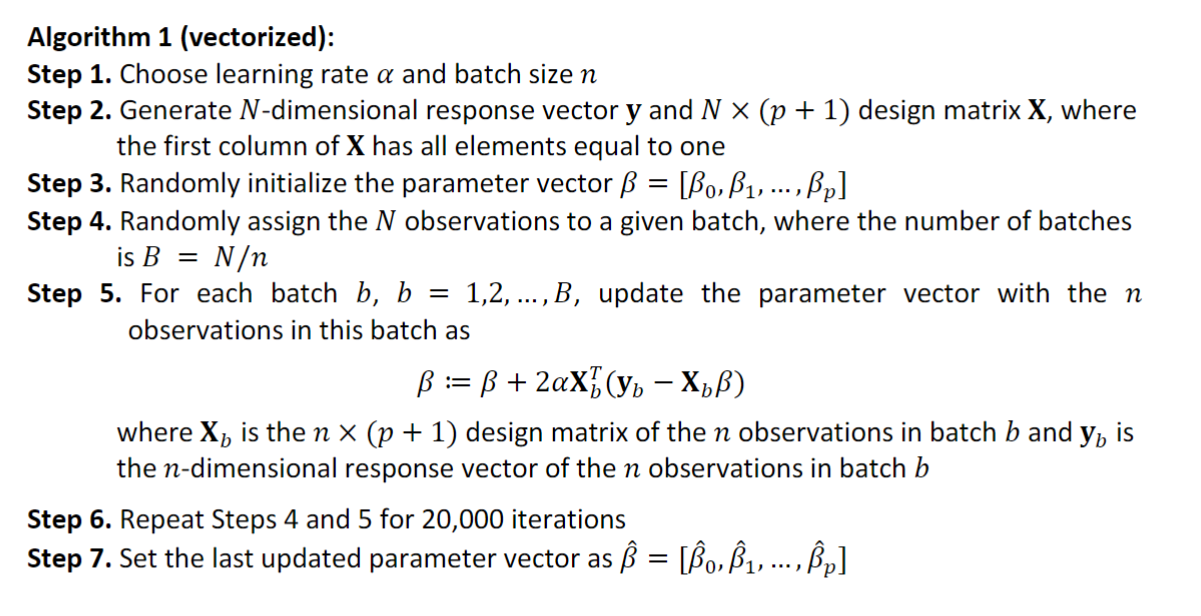

In [224]:
#Getting image
image_load = 'VectorizedAlgo3.png'

# # Display the image
Image(filename=image_load) 

In [225]:
#Below represents all the figures and requirements for the assignment
vector_param_beta = intermediary_beta
record_of_v_beta = np.array(record_of_v_beta)

In [226]:
def feature_scatter(x_feature,y_sales,xlabel,ylabel):
    plt.scatter(x_feature, y_sales)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()
    

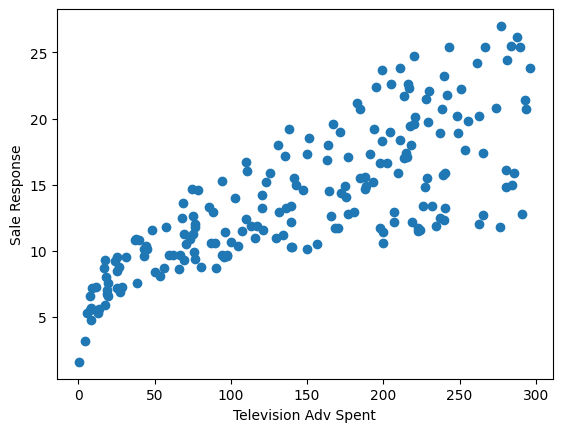

In [227]:
feature_scatter(x_features_df['TV'],y_features_df,'Television Adv Spent','Sale Response')

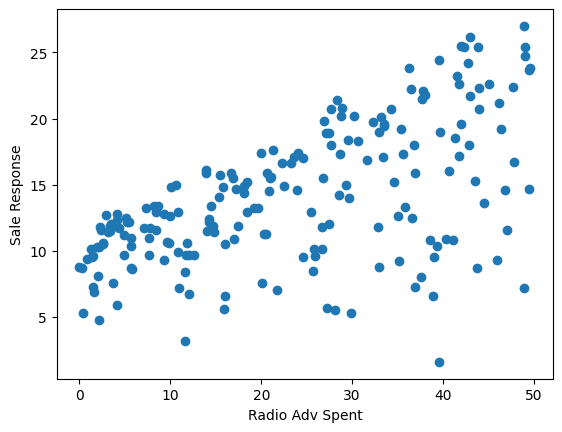

In [228]:
feature_scatter(x_features_df['radio'],y_features_df,'Radio Adv Spent','Sale Response')

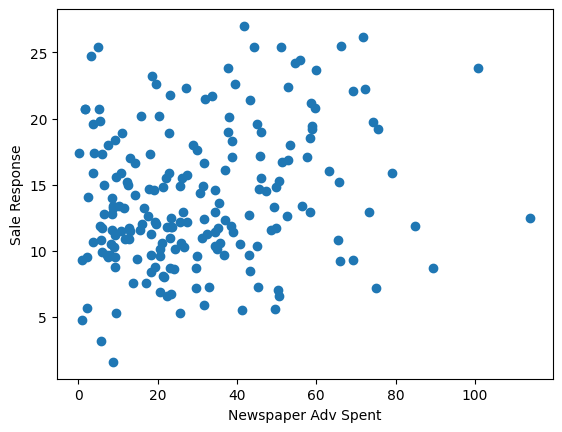

In [229]:
feature_scatter(x_features_df['newspaper'],y_features_df,'Newspaper Adv Spent','Sale Response')

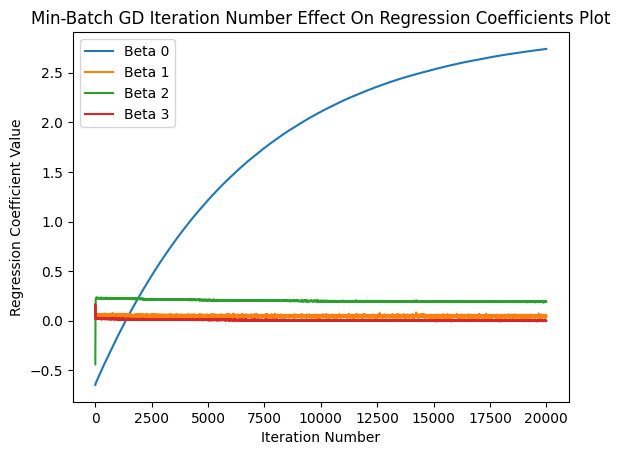

In [230]:
# Deliverable 1: Illustrate the effect of iteration number of mini-batch gradient descent on the
# inferred regression coefficients by generating a plot (e.g., using Excel, Matlab, R, etc.) of four
# lines (one for each of the 𝑝 = 3 features and the intercept), with the 𝑦-axis as 𝛽̂𝑗, 𝑗 = 0,1, ... , 𝑝,
# and the 𝑥-axis the corresponding iteration of mini-batch gradient descent that generated the
# particular 𝛽̂𝑗. Label both axes in the plot as well as the plotted lines.

    
plt.figure()

plt.plot(range(len(record_of_v_beta)), record_of_v_beta[:, 0], label='Beta '+ str(0))
plt.plot(range(len(record_of_v_beta)), record_of_v_beta[:, 1], label='Beta '+ str(1))
plt.plot(range(len(record_of_v_beta)), record_of_v_beta[:, 2], label='Beta '+ str(2))
plt.plot(range(len(record_of_v_beta)), record_of_v_beta[:, 3], label='Beta '+ str(3))


plt.xlabel('Iteration Number')
plt.ylabel('Regression Coefficient Value')


plt.title('Min-Batch GD Iteration Number Effect On Regression Coefficients Plot')

plt.legend()

plt.show()
plt.close()

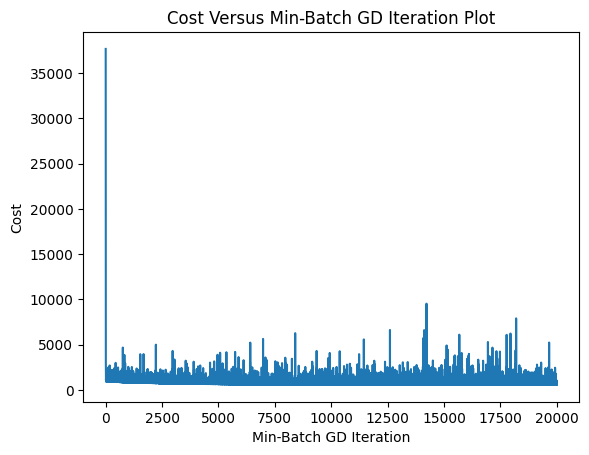

In [231]:
# Deliverable 2: Illustrate the effect of iteration number of mini-batch gradient descent on the
# cost by generating a plot (e.g., using Excel, Matlab, R, Python, etc.) with the 𝑦-axis as the cost
# 𝐽(𝛽̂ ) = (𝐲 − 𝐗𝛽̂ )𝑇(𝐲 − 𝐗𝛽̂ )
# = ∑ (𝑦𝑖 − 𝛽̂0 − ∑ 𝑥𝑖𝑗𝛽̂𝑗)^2

# and the 𝑥-axis the corresponding iteration of mini-batch gradient descent that generated the
# particular cost. Label both axes in the plot.

plt.figure()
plt.plot(range(iter_loop_size), cost_history)
plt.xlabel('Min-Batch GD Iteration')
plt.ylabel('Cost')
plt.title('Cost Versus Min-Batch GD Iteration Plot')
plt.show()
plt.close()

In [232]:
# Deliverable 3: Provide the estimates 𝛽̂ = [𝛽̂0, 𝛽̂1, ... , 𝛽̂𝑝] of the best-fit model parameters.

print("Estimates of the best-fit model parameters:")


for i in range(feature_total_p):
    print("Beta " + str(i) + " = " + str(round(vector_param_beta[i], 6)))




Estimates of the best-fit model parameters:
Beta 0 = 2.740296
Beta 1 = 0.043797
Beta 2 = 0.19178
Beta 3 = -0.002118


In [233]:
# Deliverable 4: Using the best-fit model parameters, compute the mean squared error (MSE) on
# the training set and report this value

y_predicted = X.dot(vector_param_beta)
y_actual = y
mean_squared_error = np.sum((y_actual - y_predicted)**2) / len(y_actual)

print("Mean Squared Error: " + str(round(mean_squared_error, 6)))

Mean Squared Error: 3.012545


In [234]:
# Deliverable 5: Provide all your source code that you wrote from scratch to perform all analyses
# (aside from plotting scripts, which you do not need to turn in) in this assignment, along with
# instructions on how to compile and run your code.

#CODE IS LOCATED AT TOP OF THIS ASSIGNMENT

In [235]:
# Deliverable 6 (extra credit): Upload your certificate for HackerRank Python(Basic) to the Canvas
# assignment titled “Submission of HackerRank Python(Basic) certification” before the submission
# deadline for Programming Assignment 1. This is worth up to 5% additional credit, which would
# allow you to get up to 105% out of 100 for this assignment.

#TURNED IN SEPARATELY IN DIFFERENT ASSIGNMENT AREA